In [ ]:
# EXERCICE 1 
import pandas as pd

# Charger le dataset
df = pd.read_csv("train.csv")

# Nombre de lignes avant suppression
avant = len(df)

# Supprimer les doublons
df = df.drop_duplicates()

# Afficher le nombre de doublons supprimés
print(f"Doublons supprimés : {avant - len(df)}")

Doublons supprimés : 0


In [10]:
# EXERCICE 2
import pandas as pd
from sklearn.impute import SimpleImputer

# Charger le dataset
df = pd.read_csv("train.csv")

# Afficher les valeurs manquantes
print(df.isnull().sum())

# 1. Remplacer les âges manquants par la moyenne
imputer_age = SimpleImputer(strategy="mean")
df["Age"] = imputer_age.fit_transform(df[["Age"]])

# 2. Remplacer les valeurs manquantes de Embarked par la valeur la plus fréquente
imputer_embarked = SimpleImputer(strategy="most_frequent")
df["Embarked"] = imputer_embarked.fit_transform(df[["Embarked"]]).ravel()

# 3. Remplacer les valeurs manquantes de Cabin par une constante
df["Cabin"] = df["Cabin"].fillna("Unknown")

# 4. Supprimer les lignes contenant encore des valeurs manquantes
df = df.dropna()

# Vérification finale
print("\nValeurs manquantes restantes :")
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Valeurs manquantes restantes :
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


In [11]:
# EXERCICE 3
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Charger le dataset
df = pd.read_csv("train.csv")

# Nouvelle feature : taille de la famille
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# Extraire le titre depuis Name
df["Title"] = df["Name"].str.extract(r',\s*([^\.]+)\.')

# Label Encoding pour Sex
le = LabelEncoder()
df["Sex"] = le.fit_transform(df["Sex"])

# One-Hot Encoding pour Embarked et Title
df = pd.get_dummies(df, columns=["Embarked", "Title"], drop_first=True)

# Affichage
display(df.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Title_Master,Title_Miss,Title_Mlle,Title_Mme,Title_Mr,Title_Mrs,Title_Ms,Title_Rev,Title_Sir,Title_the Countess
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,...,False,False,False,False,True,False,False,False,False,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,...,False,False,False,False,False,True,False,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,...,False,True,False,False,False,False,False,False,False,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,...,False,False,False,False,False,True,False,False,False,False
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,...,False,False,False,False,True,False,False,False,False,False


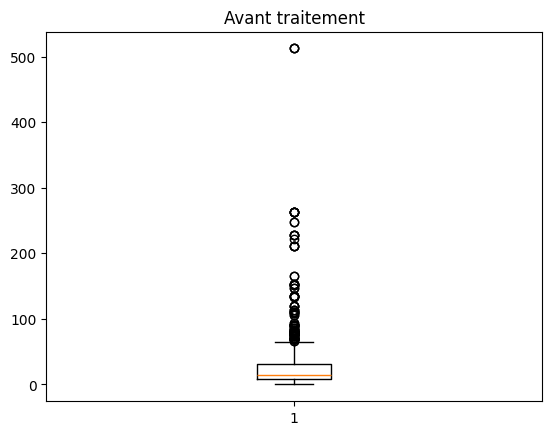

116


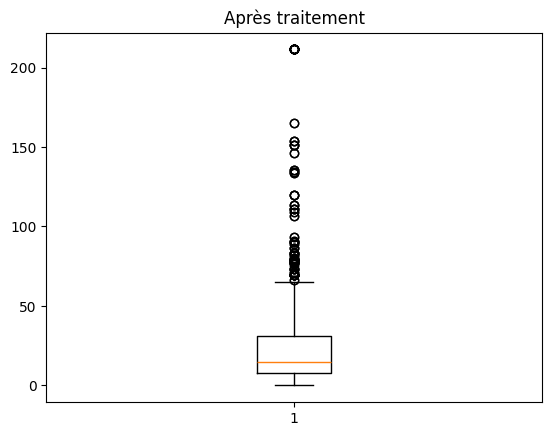

In [14]:
# EXERCICE 4
import pandas as pd
import matplotlib.pyplot as plt

# Charger le dataset
df = pd.read_csv("train.csv")

# Boxplot avant traitement
plt.boxplot(df["Fare"].dropna())
plt.title("Avant traitement")
plt.show()

# Détection avec IQR
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)

IQR = Q3 - Q1

borne_inf = Q1 - 1.5 * IQR
borne_sup = Q3 + 1.5 * IQR

# Nombre de valeurs aberrantes
print(((df["Fare"] < borne_inf) | (df["Fare"] > borne_sup)).sum())

# Traitement : plafonnement à 98%
limite = df["Fare"].quantile(0.98)

df["Fare"] = df["Fare"].clip(upper=limite)

# Boxplot après traitement
plt.boxplot(df["Fare"].dropna())
plt.title("Après traitement")
plt.show()

In [15]:
# EXERCICE 5
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Charger le dataset
df = pd.read_csv("train.csv")

# Features numériques
standard_cols = ["Age"]
minmax_cols = ["Fare"]

# Standardisation
scaler_standard = StandardScaler()
df[standard_cols] = scaler_standard.fit_transform(df[standard_cols])

# Normalisation
scaler_minmax = MinMaxScaler()
df[minmax_cols] = scaler_minmax.fit_transform(df[minmax_cols])

# Résultat
display(df[["Age", "Fare"]].head())

,Age,Fare
0,-0.530377,0.014151
1,0.571831,0.139136
2,-0.254825,0.015469
3,0.365167,0.103644
4,0.365167,0.015713


In [16]:
# EXERCICE 6
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Charger le dataset
df = pd.read_csv("train.csv")

# Créer la colonne Title
df["Title"] = df["Name"].str.extract(r',\s*([^\.]+)\.')

# Colonnes catégorielles
cat_cols = ["Sex", "Embarked", "Title"]

# One-Hot Encoding pour Embarked et Title
df = pd.get_dummies(df, columns=["Embarked", "Title"], drop_first=True)

# Label Encoding pour Sex
le = LabelEncoder()
df["Sex"] = le.fit_transform(df["Sex"])

# Vérification
display(df.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Title_Master,Title_Miss,Title_Mlle,Title_Mme,Title_Mr,Title_Mrs,Title_Ms,Title_Rev,Title_Sir,Title_the Countess
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,...,False,False,False,False,True,False,False,False,False,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,...,False,False,False,False,False,True,False,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,...,False,True,False,False,False,False,False,False,False,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,...,False,False,False,False,False,True,False,False,False,False
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,...,False,False,False,False,True,False,False,False,False,False


In [17]:
# EXERCICE 7

import pandas as pd

# Charger le dataset
df = pd.read_csv("train.csv")

# Créer des groupes d'âge
bins = [0, 12, 18, 60, 100]
labels = ["Child", "Teen", "Adult", "Senior"]

df["AgeGroup"] = pd.cut(df["Age"], bins=bins, labels=labels)

# One-Hot Encoding
df = pd.get_dummies(df, columns=["AgeGroup"], drop_first=True)

# Résultat
display(df.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeGroup_Teen,AgeGroup_Adult,AgeGroup_Senior
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,False,True,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,False,True,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,False,True,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,False,True,False
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,False,True,False
